<a href="https://colab.research.google.com/github/brightmain/Setup-Project/blob/main/regresi_sederhana.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [ ]:
import pandas as pd

data = {
    'luas_tanah': [50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 105, 110, 115, 120],
    'harga': [450, 480, 520, 560, 600, 650, 700, 750, 800, 860, 920, 980, 1050, 1120, 1200]
}

df = pd.DataFrame(data)
print("=" * 50)
print("DATA REGRESI LINEAR SEDERHANA")
print("=" * 50)
print(df)
print("\n")

DATA REGRESI LINEAR SEDERHANA
    luas_tanah  harga
0           50    450
1           55    480
2           60    520
3           65    560
4           70    600
5           75    650
6           80    700
7           85    750
8           90    800
9           95    860
10         100    920
11         105    980
12         110   1050
13         115   1120
14         120   1200




In [ ]:
X = df[['luas_tanah']]
y = df['harga']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
print("Data Training (80%):", len(X_train), "sampel")
print("Data Testing (20%):", len(X_test), "sampel")
print("\n")


Data Training (80%): 12 sampel
Data Testing (20%): 3 sampel




In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
print("=" * 50)
print("HASIL REGRESI LINEAR SEDERHANA")
print("=" * 50)
print(f"Intercept (a): {model.intercept_:.2f}")
print(f"Koefisien (b): {model.coef_[0]:.2f}")
print(f"Persamaan: Harga = {model.intercept_:.2f} + {model.coef_[0]:.2f} × Luas Tanah")
print("\n")

HASIL REGRESI LINEAR SEDERHANA
Intercept (a): -162.88
Koefisien (b): 11.03
Persamaan: Harga = -162.88 + 11.03 × Luas Tanah




In [ ]:
y_pred = model.predict(X_test)

print("Perbandingan Prediksi vs Aktual:")
print("-" * 40)
for i in range(len(X_test)):
    print(f"Luas Tanah: {X_test.iloc[i, 0]:.0f} m² | Aktual: Rp{y_test.iloc[i]:.0f} Jt | Prediksi: Rp{y_pred[i]:.0f} Jt")
print("\n")

Perbandingan Prediksi vs Aktual:
----------------------------------------
Luas Tanah: 95 m² | Aktual: Rp860 Jt | Prediksi: Rp885 Jt
Luas Tanah: 105 m² | Aktual: Rp980 Jt | Prediksi: Rp995 Jt
Luas Tanah: 50 m² | Aktual: Rp450 Jt | Prediksi: Rp389 Jt




In [ ]:
print("=" * 50)
print("EVALUASI MODEL")
print("=" * 50)
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, y_pred)

print(f"MAE  (Mean Absolute Error) : Rp{mae:.2f} Juta")
print(f"MSE  (Mean Squared Error)  : Rp{mse:.2f} Juta²")
print(f"RMSE (Root Mean Squared Error): Rp{rmse:.2f} Juta")
print(f"R² Score                    : {r2:.4f}")
print("\n")

EVALUASI MODEL
MAE  (Mean Absolute Error) : Rp33.82 Juta
MSE  (Mean Squared Error)  : Rp1540.71 Juta²
RMSE (Root Mean Squared Error): Rp39.25 Juta
R² Score                    : 0.9701




In [ ]:
print("=" * 50)
print("PREDIKSI DATA BARU")
print("=" * 50)
luas_baru = [[130], [140], [150]]
prediksi_baru = model.predict(luas_baru)

for i, luas in enumerate(luas_baru):
    print(f"Luas tanah {luas[0]} m² → Prediksi harga: Rp{prediksi_baru[i]:.0f} Juta")
print("\n")


PREDIKSI DATA BARU
Luas tanah 130 m² → Prediksi harga: Rp1271 Juta
Luas tanah 140 m² → Prediksi harga: Rp1381 Juta
Luas tanah 150 m² → Prediksi harga: Rp1491 Juta




/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


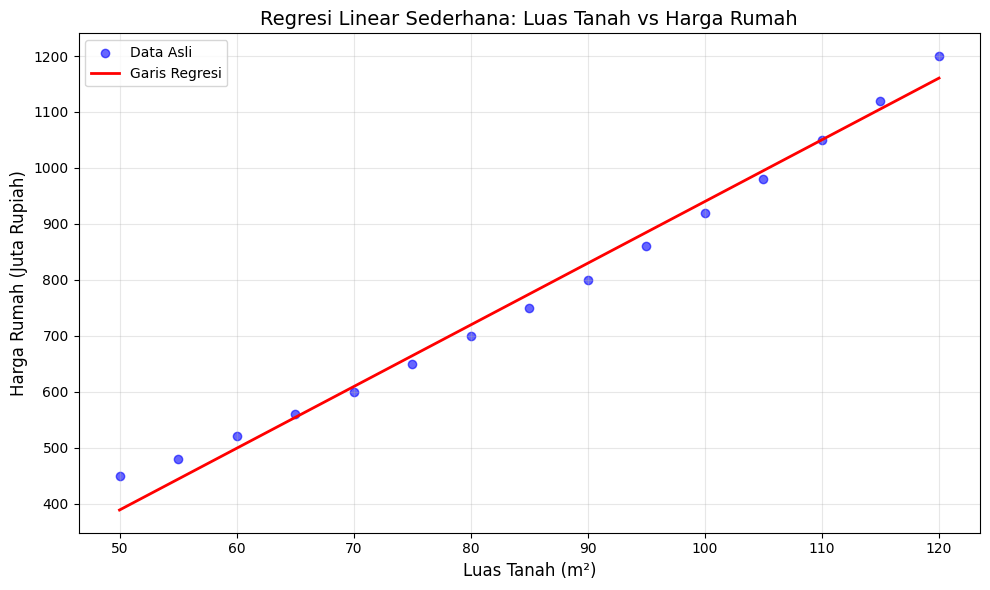

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Data Asli', alpha=0.6)
plt.plot(X, model.predict(X), color='red', linewidth=2, label='Garis Regresi')
plt.xlabel("Luas Tanah (m²)", fontsize=12)
plt.ylabel("Harga Rumah (Juta Rupiah)", fontsize=12)
plt.title("Regresi Linear Sederhana: Luas Tanah vs Harga Rumah", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()